In [ ]:
!pip install yfinance scikit-learn


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8")


In [ ]:
stocks = [
    "AAPL","MSFT","GOOGL","AMZN","META",
    "NVDA","TSLA","JPM","V","MA",
    "UNH","HD","PG","DIS","BAC",
    "XOM","KO","PFE","INTC","CSCO"
]

start = "2015-01-01"

data = yf.download(stocks, start=start)["Close"]

# Remove stocks with too many missing values
data = data.dropna(axis=1)

print("Shape after cleaning:", data.shape)

data.head()


/tmp/ipython-input-1711155301.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start=start)["Close"]
[*********************100%***********************]  20 of 20 completed


Shape after cleaning: (2796, 20)


Ticker,AAPL,AMZN,BAC,CSCO,DIS,GOOGL,HD,INTC,JPM,KO,MA,META,MSFT,NVDA,PFE,PG,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,24.214899,15.4260,14.203640,19.710138,85.365944,26.278946,79.901909,27.896450,46.511131,29.783405,79.985512,77.905807,39.858463,0.483011,18.381014,66.049393,14.620667,84.480499,61.214745,57.533417
2015-01-05,23.532726,15.1095,13.791023,19.317507,84.118462,25.778227,78.225525,27.581892,45.067192,29.783405,77.735695,76.654533,39.491920,0.474853,18.281275,65.735344,14.006000,83.088974,59.863510,55.959202
2015-01-06,23.534935,14.7645,13.378404,19.310368,83.672279,25.142036,77.986046,27.067846,43.898643,30.009569,77.567642,75.621765,38.912277,0.460456,18.433819,65.435936,14.085333,82.921310,59.477764,55.661709
2015-01-07,23.864946,14.9210,13.441889,19.488838,84.528221,25.068092,80.658989,27.635601,43.965641,30.384165,78.774261,75.621765,39.406681,0.459257,18.686098,65.779144,14.063333,83.767967,60.274632,56.225693
2015-01-08,24.781893,15.0230,13.719609,19.638752,85.402359,25.155432,82.443512,28.149630,44.948105,30.751678,79.999542,77.637680,40.565956,0.476533,19.067446,66.531387,14.041333,87.766472,61.083065,57.161579


In [ ]:
rets = data.pct_change()

# Drop rows where too many NaNs
rets = rets.dropna()

print("Returns shape:", rets.shape)
rets.head()


Returns shape: (2795, 20)


Ticker,AAPL,AMZN,BAC,CSCO,DIS,GOOGL,HD,INTC,JPM,KO,MA,META,MSFT,NVDA,PFE,PG,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.020517,-0.029050,-0.019920,-0.014613,-0.019054,-0.020981,-0.011276,-0.031045,0.000000,-0.028128,-0.016061,-0.009196,-0.016890,-0.005426,-0.004755,-0.042041,-0.016472,-0.022074,-0.027362
2015-01-06,0.000094,-0.022833,-0.029919,-0.000370,-0.005304,-0.024679,-0.003061,-0.018637,-0.025929,0.007594,-0.002162,-0.013473,-0.014678,-0.030318,0.008344,-0.004555,0.005664,-0.002018,-0.006444,-0.005316
2015-01-07,0.014022,0.010600,0.004745,0.009242,0.010230,-0.002941,0.034275,0.020975,0.001526,0.012483,0.015556,0.000000,0.012706,-0.002606,0.013686,0.005245,-0.001562,0.010210,0.013398,0.010132
2015-01-08,0.038422,0.006836,0.020661,0.007692,0.010341,0.003484,0.022124,0.018600,0.022346,0.012096,0.015554,0.026658,0.029418,0.037618,0.020408,0.011436,-0.001564,0.047733,0.013413,0.016645
2015-01-09,0.001073,-0.011749,-0.017929,0.010178,0.004905,-0.012211,-0.017148,0.001908,-0.017387,-0.011032,-0.012744,-0.005628,-0.008405,0.004028,0.004615,-0.009331,-0.018802,-0.009360,-0.014823,-0.001410


In [ ]:
rets_short = rets.iloc[-500:]   # last ~2 years

print("Shape:", rets_short.shape)


Shape: (500, 20)


In [ ]:
# Standardize returns (convert to correlation structure)

rets_std = (rets_short - rets_short.mean()) / rets_short.std()

print("Mean (should be ~0):")
print(rets_std.mean().mean())

print("Std (should be ~1):")
print(rets_std.std().mean())


Mean (should be ~0):
4.242439732848879e-18
Std (should be ~1):
1.0


In [ ]:
from sklearn.decomposition import PCA

# PCA on standardized returns
pca = PCA()
pca.fit(rets_std)

eigs = pca.explained_variance_

# RMT threshold
T, N = rets_std.shape
q = T / N

lambda_max = (1 + np.sqrt(1/q))**2

print("Noise Threshold:", round(lambda_max,3))
print("Eigenvalues:", np.round(eigs,3))
print("Signal Factors:", sum(eigs > lambda_max))



Noise Threshold: 1.44
Eigenvalues: [6.168 2.618 1.254 1.096 0.995 0.797 0.773 0.757 0.732 0.675 0.622 0.585
 0.509 0.473 0.449 0.438 0.402 0.33  0.204 0.122]
Signal Factors: 2


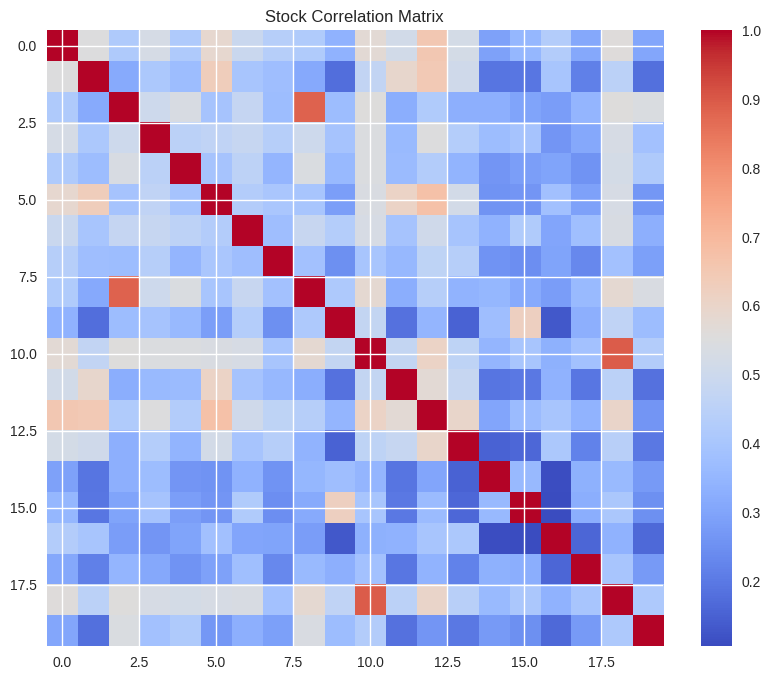

In [ ]:
corr = rets.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.title("Stock Correlation Matrix")
plt.show()


In [ ]:
print(data.shape)
print(rets.shape)
print(rets.head())


(2796, 20)
(2795, 20)
Ticker          AAPL      AMZN       BAC      CSCO       DIS     GOOGL  \
Date                                                                     
2015-01-05 -0.028172 -0.020517 -0.029050 -0.019920 -0.014613 -0.019054   
2015-01-06  0.000094 -0.022833 -0.029919 -0.000370 -0.005304 -0.024679   
2015-01-07  0.014022  0.010600  0.004745  0.009242  0.010230 -0.002941   
2015-01-08  0.038422  0.006836  0.020661  0.007692  0.010341  0.003484   
2015-01-09  0.001073 -0.011749 -0.017929  0.010178  0.004905 -0.012211   

Ticker            HD      INTC       JPM        KO        MA      META  \
Date                                                                     
2015-01-05 -0.020981 -0.011276 -0.031045  0.000000 -0.028128 -0.016061   
2015-01-06 -0.003061 -0.018637 -0.025929  0.007594 -0.002162 -0.013473   
2015-01-07  0.034275  0.020975  0.001526  0.012483  0.015556  0.000000   
2015-01-08  0.022124  0.018600  0.022346  0.012096  0.015554  0.026658   
2015-01-09 -0.0

In [ ]:
pca = PCA()
pca.fit(rets)

eigenvals = pca.explained_variance_
eigenvecs = pca.components_


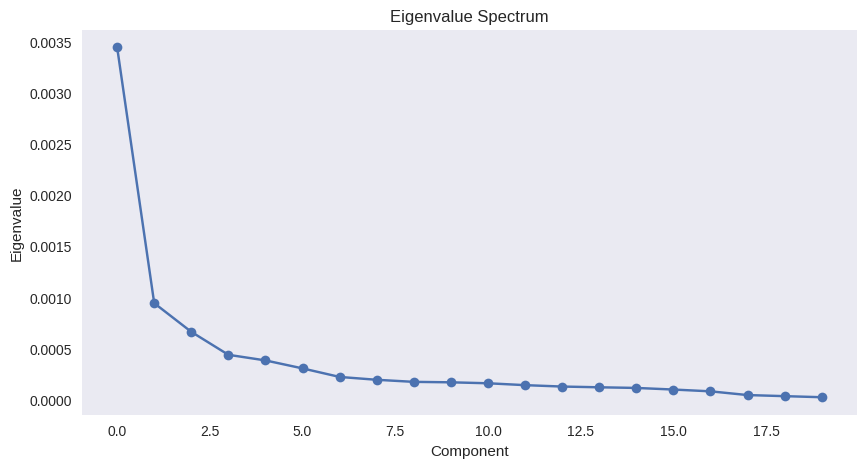

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(eigenvals, marker="o")

plt.title("Eigenvalue Spectrum")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")

plt.grid()
plt.show()


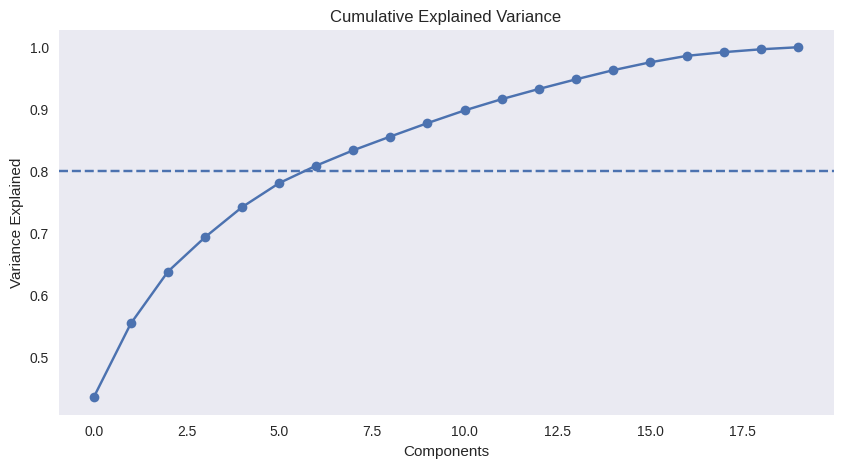

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(0.8, linestyle="--")

plt.title("Cumulative Explained Variance")
plt.xlabel("Components")
plt.ylabel("Variance Explained")

plt.grid()
plt.show()


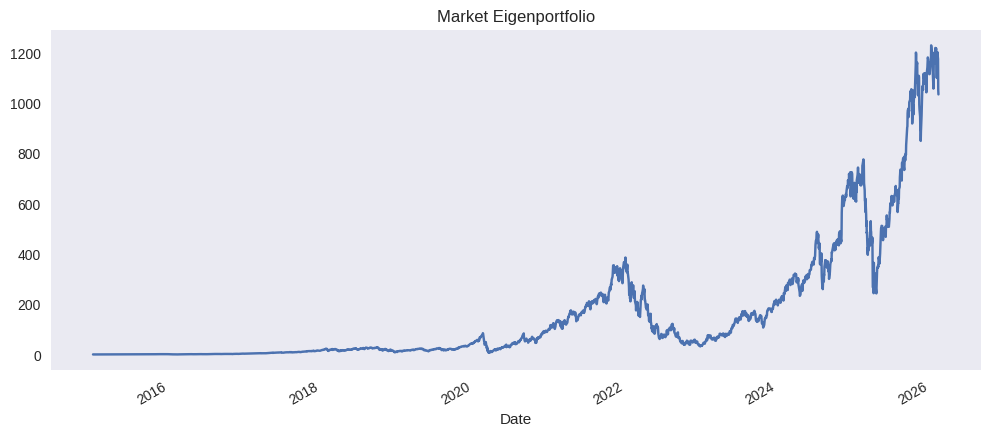

In [ ]:
market_weights = eigenvecs[0]

market_pf = (
    rets @ market_weights
)

plt.figure(figsize=(12,5))

(1+market_pf).cumprod().plot()

plt.title("Market Eigenportfolio")
plt.grid()
plt.show()


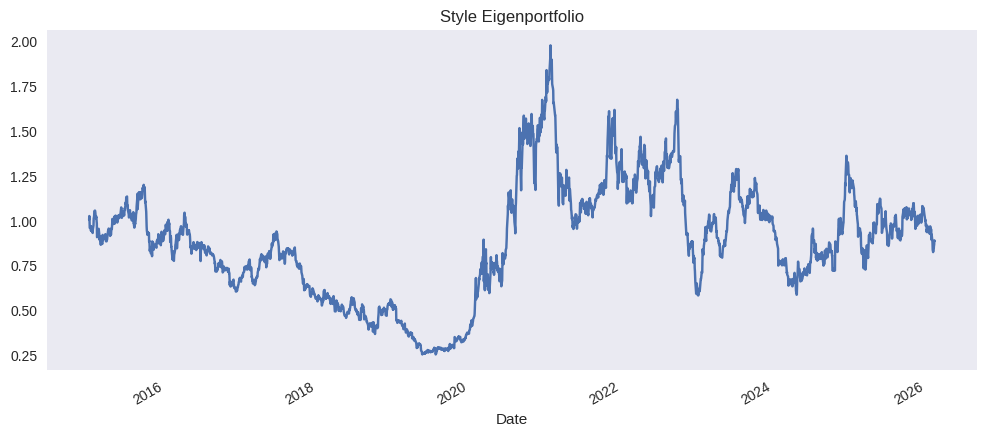

In [ ]:
style_weights = eigenvecs[1]

style_pf = rets @ style_weights


plt.figure(figsize=(12,5))

(1+style_pf).cumprod().plot()

plt.title("Style Eigenportfolio")
plt.grid()
plt.show()


In [ ]:
T, N = rets.shape

q = T/N

lambda_max = (1 + np.sqrt(1/q))**2

print("Noise Threshold:", round(lambda_max,3))


Noise Threshold: 1.176


In [ ]:
# PCA + RMT on STANDARDIZED returns (correct way)

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(rets_std)   # ✅ MUST be rets_std

eigenvals = pca.explained_variance_

T, N = rets_std.shape
q = T / N

lambda_max = (1 + np.sqrt(1/q))**2


signal_eigs = eigenvals[eigenvals > lambda_max]


print("Noise Threshold:", round(lambda_max,3))
print("Eigenvalues:", np.round(eigenvals,3))

print("Total components:", len(eigenvals))
print("Signal factors:", len(signal_eigs))


Noise Threshold: 1.44
Eigenvalues: [6.168 2.618 1.254 1.096 0.995 0.797 0.773 0.757 0.732 0.675 0.622 0.585
 0.509 0.473 0.449 0.438 0.402 0.33  0.204 0.122]
Total components: 20
Signal factors: 2


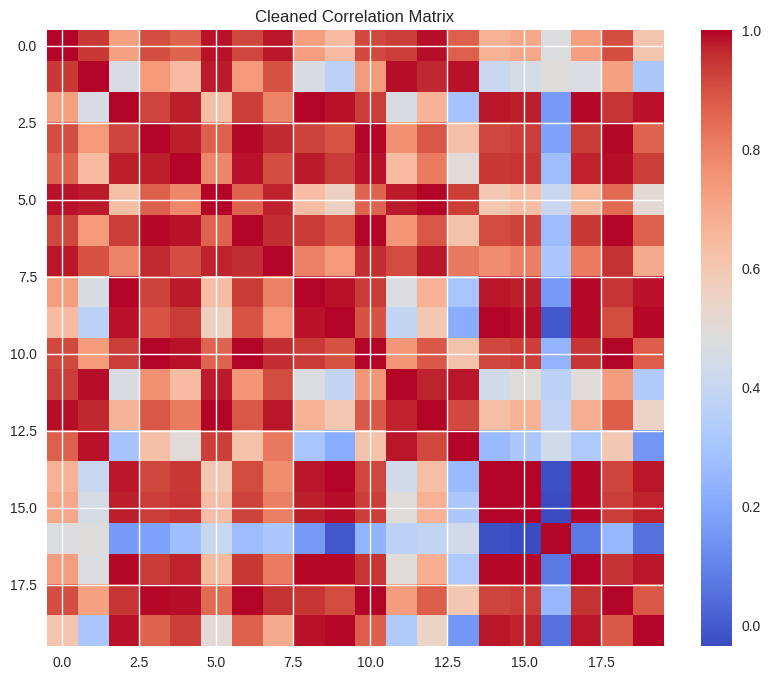

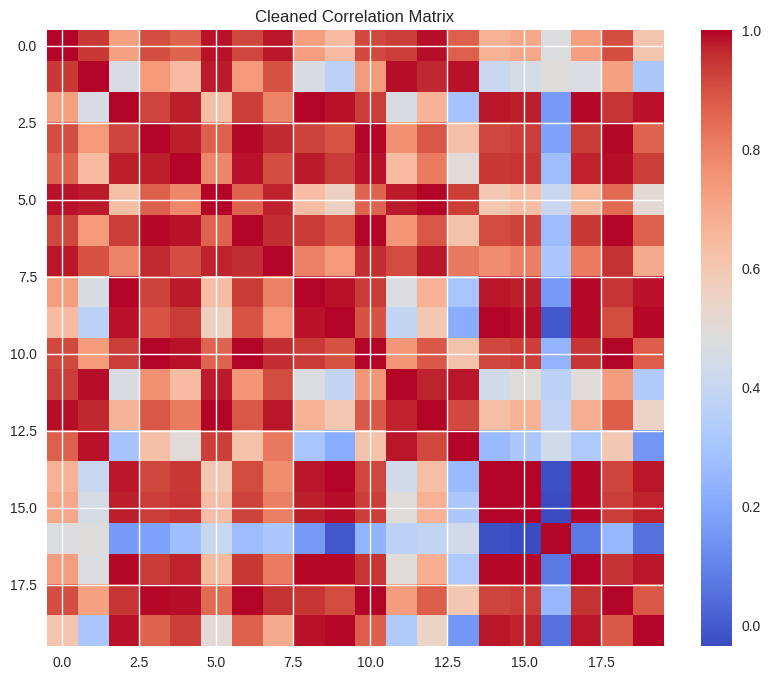

In [ ]:
clean_corr = np.zeros(corr.shape)

for i in range(len(eigenvals)):

    if eigenvals[i] > lambda_max:

        v = eigenvecs[i].reshape(-1,1)

        clean_corr += eigenvals[i] * (v @ v.T)


# Normalize
D = np.sqrt(np.diag(clean_corr))
clean_corr = clean_corr / D[:,None] / D[None,:]


plt.figure(figsize=(10,8))
plt.imshow(clean_corr, cmap="coolwarm")
plt.colorbar()

plt.title("Cleaned Correlation Matrix")
plt.show()
clean_corr = np.zeros(corr.shape)

for i in range(len(eigenvals)):

    if eigenvals[i] > lambda_max:

        v = eigenvecs[i].reshape(-1,1)

        clean_corr += eigenvals[i] * (v @ v.T)


# Normalize
D = np.sqrt(np.diag(clean_corr))
clean_corr = clean_corr / D[:,None] / D[None,:]


plt.figure(figsize=(10,8))
plt.imshow(clean_corr, cmap="coolwarm")
plt.colorbar()

plt.title("Cleaned Correlation Matrix")
plt.show()


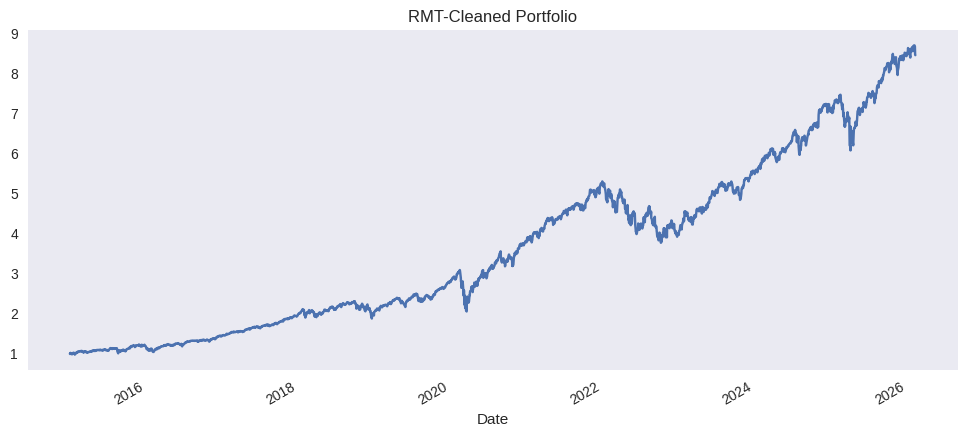

In [ ]:
inv_var = 1/np.diag(clean_corr)

weights = inv_var / inv_var.sum()

pf_rets = rets @ weights


plt.figure(figsize=(12,5))

(1+pf_rets).cumprod().plot()

plt.title("RMT-Cleaned Portfolio")
plt.grid()
plt.show()


Factor1 shape: (500,)
Factor2 shape: (500,)


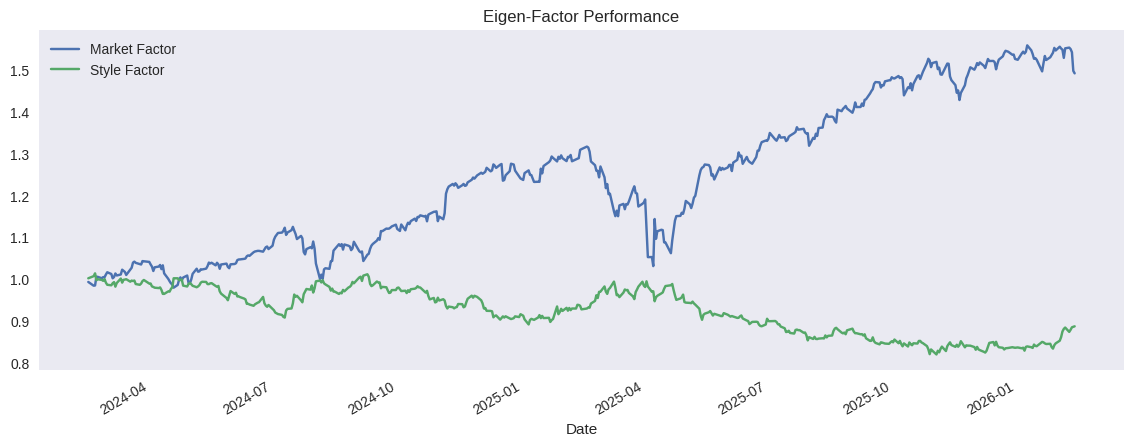

In [ ]:
# Build eigenportfolios (factors)

# First two eigenvectors
v1 = pca.components_[0]
v2 = pca.components_[1]


# Normalize weights
v1 = v1 / np.sum(np.abs(v1))
v2 = v2 / np.sum(np.abs(v2))


# Factor returns
factor1 = rets_short @ v1
factor2 = rets_short @ v2


print("Factor1 shape:", factor1.shape)
print("Factor2 shape:", factor2.shape)


# Plot factors
plt.figure(figsize=(14,5))

(1+factor1).cumprod().plot(label="Market Factor")
(1+factor2).cumprod().plot(label="Style Factor")

plt.title("Eigen-Factor Performance")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Lookback window (~12 months)
lookback = 252


# Rolling momentum
mom1 = factor1.rolling(lookback).mean()
mom2 = factor2.rolling(lookback).mean()


# Trading signals
sig1 = np.sign(mom1)
sig2 = np.sign(mom2)


# Shift to avoid lookahead
sig1 = sig1.shift(1)
sig2 = sig2.shift(1)


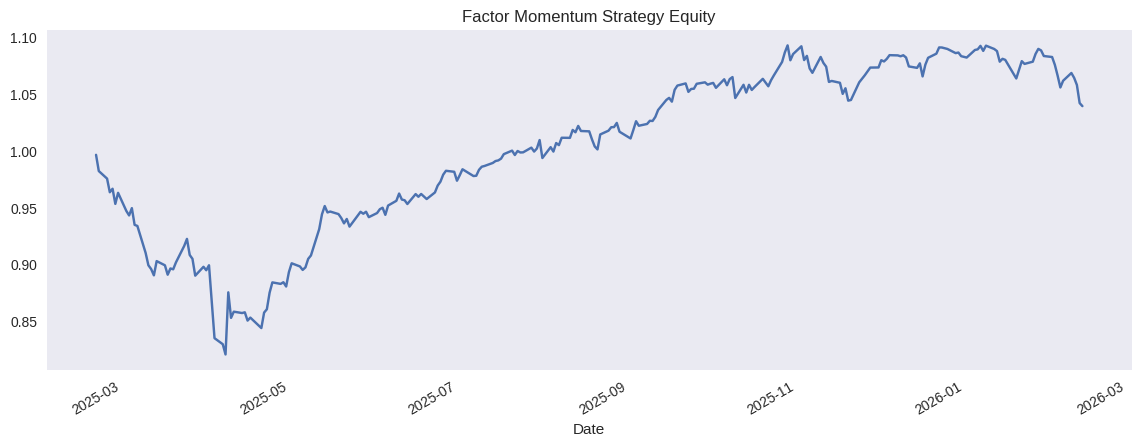

In [ ]:
# Combine factor signals
strategy_rets = (
    0.5 * sig1 * factor1 +
    0.5 * sig2 * factor2
)

strategy_rets = strategy_rets.dropna()


# Equity curve
equity = (1 + strategy_rets).cumprod()


plt.figure(figsize=(14,5))
equity.plot()

plt.title("Factor Momentum Strategy Equity")
plt.grid()
plt.show()


In [ ]:
def sharpe(rets):
    return np.sqrt(252) * rets.mean() / rets.std()


def max_dd(eq):
    return (eq/eq.cummax() - 1).min()


print("Sharpe:", round(sharpe(strategy_rets),2))
print("Max DD:", round(max_dd(equity)*100,2),"%")
print("Total Return:", round((equity.iloc[-1]-1)*100,2),"%")


Sharpe: 0.34
Max DD: -17.65 %
Total Return: 3.94 %
